## Define the graph functions

In [1]:
import mlrun

project = mlrun.get_or_create_project("test-notebooks", user_project=True)

> 2026-03-09 08:25:01,195 [info] Project loaded successfully: {"project_name":"test-notebooks-iguazio"}


In [2]:
%%writefile func.py

def router(event):
    print(f"event is : {event}")
    # Decide where to route based on the value
    if isinstance(event["value"], dict):
        event["route"] = "dict"
    elif isinstance(event["value"],list):
        event["route"] = "list"
    else:
        raise AttributeError("Key 'route' in event must be either dict or list")
    return event

def handle_dict(event):
    event["sum"] = sum(event["value"].values())
    return event

def handle_list(event):
    event["sum"] = sum(event["value"])
    return event

def pprint(event):
    print(f"sum is : {event['sum']}")
    return event

Overwriting func.py


## Create a serving function and set the graph

In [3]:
serving_fn = project.set_function(name='my-graph', kind="serving", image="mlrun/mlrun", func="func.py")

In [4]:
from mlrun.serving.steps import ChoiceByField


graph = serving_fn.set_topology("flow", engine="async", exist_ok=True)

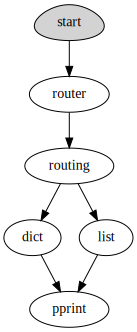

In [5]:
graph.add_step(name="router", handler="router")
graph.add_step(class_name=ChoiceByField("route"), name="routing", after=["router"])
graph.add_step(name="dict", handler="handle_dict", after=["routing"])
graph.add_step(name="list", handler="handle_list", after=["routing"])
graph.add_step(name="pprint", handler="pprint", after=["dict", "list"]).respond()
graph.plot()

## test locally

In [6]:
server = serving_fn.to_mock_server()

try:
    resp = server.test(body={"value": [1,2,3,4]})
except Exception as e:
    raise e
finally:
    server.wait_for_completion()
assert resp['sum'] == 10

event is : {'value': [1, 2, 3, 4]}
sum is : 10
> 2026-03-09 08:25:04,305 [info] Forwarding termination signal from step 'SyncEmitSource' to steps: router
> 2026-03-09 08:25:04,306 [info] Forwarding termination signal from step 'router' to steps: routing
> 2026-03-09 08:25:04,306 [info] Forwarding termination signal from step 'routing' to steps: dict, list
> 2026-03-09 08:25:04,307 [info] Forwarding termination signal from step 'dict' to steps: pprint
> 2026-03-09 08:25:04,307 [info] Forwarding termination signal from step 'list' to steps: pprint
> 2026-03-09 08:25:04,308 [info] Forwarding termination signal from step 'pprint' to steps: Complete


## test remotely

In [7]:
serving_fn.deploy()

> 2026-03-09 08:25:04,315 [info] Starting remote function deploy
2026-03-09 08:25:04  (info) Deploying function
2026-03-09 08:25:04  (info) Building
2026-03-09 08:25:04  (info) Staging files and preparing base images
2026-03-09 08:25:04  (warn) Using user provided base image, runtime interpreter version is provided by the base image
2026-03-09 08:25:04  (info) Building processor image
2026-03-09 08:26:57  (info) Build complete
2026-03-09 08:27:06  (info) Function deploy complete
> 2026-03-09 08:27:08,234 [info] Model endpoint creation task completed with state succeeded
> 2026-03-09 08:27:08,234 [info] Successfully deployed function: {"external_invocation_urls":["test-notebooks-iguazio-my-graph.default-tenant.app.vmdev67.lab.iguazeng.com/"],"internal_invocation_urls":["nuclio-test-notebooks-iguazio-my-graph.default-tenant.svc.cluster.local:8080"]}


'http://test-notebooks-iguazio-my-graph.default-tenant.app.vmdev67.lab.iguazeng.com/'

In [8]:
try:
    resp = serving_fn.invoke("/", body={"value": {"key1": 1, "key2": 2, "key3": 3}})
except Exception as e:
    raise e
assert resp['sum'] == 6